# 2. Return distributions

**Question:** what do equity returns actually look like, and does the normal distribution
describe them?

The analysis uses the MSCI World ETF (EUNL, in EUR) at daily and monthly frequency, plus the
developed-market proxy back to 1999.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from investor_toolkit.plotting import apply_style

warnings.filterwarnings("ignore", category=FutureWarning)
apply_style()
pd.set_option("display.precision", 3)
pd.set_option("display.width", 120)
FIGURES = "../docs/figures"

from scipy import stats

from investor_toolkit import proxies, universe
from investor_toolkit import returns as rt
from investor_toolkit.plotting import plot_return_distribution

In [2]:
prices = universe.load_asset_prices(["EUNL.DE"])["EUNL.DE"].dropna()
daily = rt.simple_returns(prices).loc["2009-12-31":]
monthly = universe.load_asset_returns(["EUNL.DE"])["EUNL.DE"]
long_monthly = proxies.long_history()["world_equity"]

pd.DataFrame(
    {
        "daily (ETF)": rt.moments(daily),
        "monthly (ETF)": rt.moments(monthly),
        "monthly (proxy, 1999-)": rt.moments(long_monthly),
    }
).T

,n,mean,std,skew,excess_kurtosis
daily (ETF),4256.0,5.146e-04,0.010,-0.660,7.554
monthly (ETF),204.0,1.056e-02,0.036,-0.360,0.768
"monthly (proxy, 1999-)",331.0,7.207e-03,0.041,-0.531,0.763


A normal distribution has zero skewness and zero excess kurtosis. Daily returns are clearly
left-skewed and heavy-tailed. Monthly returns are much closer to normal: sums of many daily
returns tend towards a normal distribution (aggregational Gaussianity), although the left skew
persists.

## Normal vs Student-t

Both distributions are fitted by maximum likelihood. Lower AIC/BIC is better; the KS statistic is
the largest gap between the fitted and empirical cumulative distribution.

In [3]:
daily_fits = rt.compare_fits(daily)
monthly_fits = rt.compare_fits(monthly)
pd.concat({"daily": daily_fits, "monthly": monthly_fits})

loc  scale  log_likelihood        aic        bic  ks_statistic     df
daily   normal     5.146e-04  0.010       13711.153 -27418.306 -27405.594         0.080    NaN
        student_t  8.699e-04  0.006       14150.573 -28295.147 -28276.078         0.014  3.137
monthly normal     1.056e-02  0.036         391.080   -778.160   -771.524         0.063    NaN
        student_t  1.167e-02  0.030         393.352   -780.704   -770.750         0.035  7.189

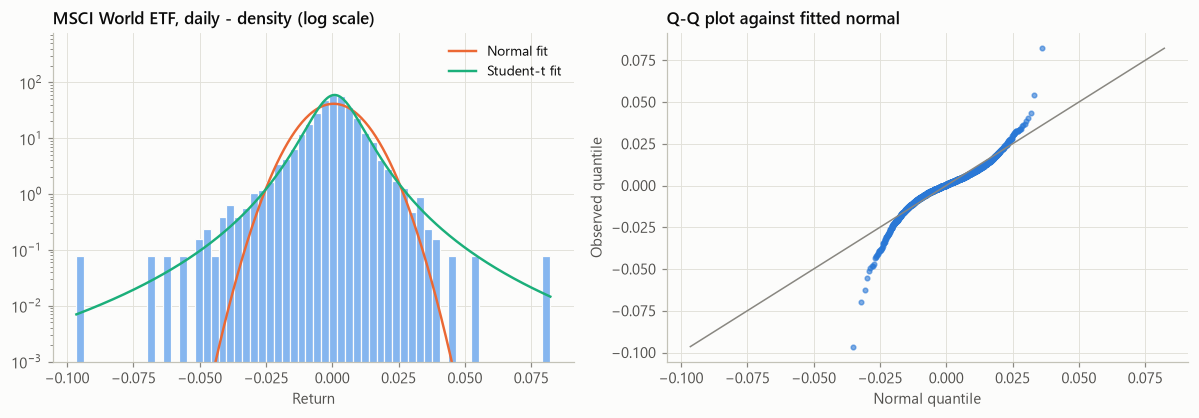

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
plot_return_distribution(
    daily, rt.fit_normal(daily), rt.fit_student_t(daily), axes=axes, title="MSCI World ETF, daily"
)
fig.tight_layout()
fig.savefig(f"{FIGURES}/return_distribution.png")

For daily data the Student-t wins on every criterion. For monthly data the two are close: AIC
still prefers the Student-t, while BIC, which penalises the extra parameter more, prefers the
normal distribution.

On a log density scale the difference is in the tails: the normal density falls off as
$e^{-x^2}$ and assigns almost no probability to the largest days, while the Student-t, whose tail
decays as a power law, follows them. The Q-Q plot shows the same thing: observed extreme
quantiles lie far outside the normal line on both ends.

## How often do extreme days occur?

In [5]:
rt.tail_frequencies(daily)

,observed,expected_normal,ratio
2 sigma,226.0,193.649,1.167
3 sigma,72.0,11.490,6.266
4 sigma,24.0,0.270,89.026
5 sigma,10.0,0.002,4098.397


Moves beyond three standard deviations happen several times more often than the normal
distribution predicts; beyond four and five, by orders of magnitude.

Part of this is **volatility clustering**: calm and turbulent periods alternate, and one normal
distribution fitted to both misjudges each. Dividing every day by the volatility forecast made
just before it (an exponentially weighted moving average, `returns.ewma_standardize`) removes
that effect:

In [6]:
conditional = rt.ewma_standardize(daily)
whole_period = (daily - daily.mean()) / daily.std(ddof=1)
pd.DataFrame(
    {
        f"{k} sigma": {
            "whole-period volatility": int(np.sum(np.abs(whole_period) > k)),
            "recent volatility (EWMA)": int(np.sum(np.abs(conditional) > k)),
            "normal, expected": round(len(daily) * 2 * stats.norm.sf(k), 3),
        }
        for k in (3, 4, 5)
    }
).T

,whole-period volatility,recent volatility (EWMA),"normal, expected"
3 sigma,72.0,54.0,11.490
4 sigma,24.0,26.0,0.270
5 sigma,10.0,4.0,0.002


Clustering explains part of the excess, but not all of it: even measured against recent
volatility, extreme days remain far more frequent than a normal distribution allows. Risk models
need both a time-varying volatility and fat tails.

The **Hill estimator** measures how fast the tail decays, $P(|X| > x) \sim x^{-\alpha}$. A smaller
$\alpha$ means a fatter tail; variance is infinite for $\alpha \le 2$ and kurtosis for
$\alpha \le 4$.

In [7]:
pd.DataFrame(
    {
        fraction: {side: rt.hill_tail_index(daily, fraction, side) for side in ("left", "right")}
        for fraction in (0.02, 0.05, 0.10)
    }
).rename_axis(index="tail", columns="tail fraction")

tail fraction,0.02,0.05,0.10
tail,,,
left,2.853,2.419,1.995
right,3.797,2.936,2.446


The left tail (losses) has a lower index than the right tail (gains): crashes are more extreme
than rallies. The estimate depends on how much of the sample is treated as tail, which is
the main practical limitation of the method.

## Does volatility scale with the square root of time?

If returns are uncorrelated, the variance of $h$-period returns is $h$ times the one-period
variance, so volatility scales with $\sqrt{h}$. The variance-ratio test (Lo and MacKinlay, 1988)
checks this; $VR > 1$ indicates trending, $VR < 1$ mean reversion.

In [8]:
rows = []
for label, series in [("daily ETF", daily), ("monthly proxy", long_monthly)]:
    for q in (2, 4, 12):
        result = rt.variance_ratio_test(np.log1p(series), q)
        rows.append(
            {
                "series": label,
                "q": q,
                "VR": result.variance_ratio,
                "z": result.z_statistic,
                "p_value": result.p_value,
            }
        )
pd.DataFrame(rows).set_index(["series", "q"])

VR      z  p_value
series        q                        
daily ETF     2   0.974 -0.898    0.369
              4   0.970 -0.576    0.564
              12  0.942 -0.573    0.567
monthly proxy 2   1.106  1.469    0.142
              4   1.191  1.447    0.148
              12  1.512  2.062    0.039

In [9]:
rt.horizon_volatility(np.log1p(daily), horizons=(1, 5, 21, 63, 252))

,observed,sqrt_h_scaling,ratio
horizon,,,
1,0.010,0.010,1.000
5,0.021,0.022,0.980
21,0.042,0.044,0.952
63,0.063,0.077,0.823
252,0.100,0.154,0.653


At daily-to-monthly horizons the square-root rule holds well. At longer horizons the evidence is
weak in both directions: annual volatility of the ETF is below the square-root-of-time value, but
that estimate rests on fewer than twenty independent years, and the longer monthly proxy points
the other way. The square-root rule is therefore a reasonable default, with substantial
uncertainty at multi-year horizons.

**Takeaways**

* Daily equity returns are fat-tailed and left-skewed; a Student-t with few degrees of freedom
  describes them far better than a normal distribution.
* Aggregating to monthly returns brings the distribution closer to normal, which justifies
  simpler models for long-horizon planning (see notebook 7).
* Losses are more extreme than gains.